# procesamiento de señales aplicado en el terremoto de Maule

ocurrido el 27 de febrero de 2010 frente a la costa de la región del Maule (Chile).



In [ ]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import pandas as pd


event_client = Client("USGS")
waveform_client = Client("IRIS")

/home/ezequel/.local/lib/python3.8/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


### Busqueda del evento en el catálogo de obspy

Se filtra por rango de fechas, magnitud y ubicación aproximada (frente a la costa centro-sur de Chile).

In [ ]:
t0 = UTCDateTime("2010-02-27T00:00:00")
t1 = UTCDateTime("2010-02-27T12:00:00")

catalog = event_client.get_events(
    starttime=t0,
    endtime=t1,
    minmagnitud=8.0, #tener en cuenta que fue de 8.2
    maxmagnitud=9.0,
    minlatitude=-40,
    maxlatitude=-30,
    minlongitude=-75,
    maxlongitude=-70,
)

print(catalog)
event = catalog[0]
print(event)

1 Event(s) in Catalog:
2010-02-27T06:34:11.530000Z | -36.122,  -72.898 | 8.8  mww | manual
Event:	2010-02-27T06:34:11.530000Z | -36.122,  -72.898 | 8.8  mww | manual

	            resource_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/fdsnws/event/1/query?eventid=official20100227063411530_30&format=quakeml")
	             event_type: 'earthquake'
	          creation_info: CreationInfo(agency_id='official', creation_time=UTCDateTime(2026, 7, 12, 19, 28, 40, 54000))
	    preferred_origin_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/product/origin/official20100227063411530_30/official/1478119680198")
	 preferred_magnitude_id: ResourceIdentifier(id="quakeml:earthquake.usgs.gov/product/origin/official20100227063411530_30/official/1478119680198#magnitude")
	                   ---------
	     event_descriptions: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements


In [ ]:
origen = event.preferred_origen() or event.origens[0]
magnitud = event.preferred_magnitud() or event.magnituds[0]

origen = origen.time
print(f"Hora origen: {origen}")
print(f"Latitud:     {origen.latitude}")
print(f"Longitud:    {origen.longitude}")
print(f"Profundidad: {origen.depth / 1000:.1f} km")
print(f"Magnitud:    {magnitud.mag} {magnitud.magnitud_type}")

Hora origen: 2010-02-27T06:34:11.530000Z
Latitud:     -36.122
Longitud:    -72.898
Profundidad: 22.9 km
Magnitud:    8.8 mww


#### descarga de la forma de onda

Se elige arbitrariamente IU.LVC (Limón Verde, Chile), canal BHZ vertical, banda ancha, y una ventana de 1 minuto antes y 30 minutos después del origen del sismo.

el resultado es una traza sismica, objeto de obspy bajo el cual se puede plotear y hacer varias cosas más. 

In [ ]:
network = "IU"
station = "LVC"
location = "00"
channel = "BHZ"

st = waveform_client.get_waveforms(
    network=network,
    station=station,
    location=location,
    channel=channel,
    starttime=origen - 60,
    endtime=origen + 1800,
)

print(st)


1 Trace(s) in Stream:
IU.LVC.00.BHZ | 2010-02-27T06:33:11.569538Z - 2010-02-27T07:04:11.519538Z | 20.0 Hz, 37200 samples


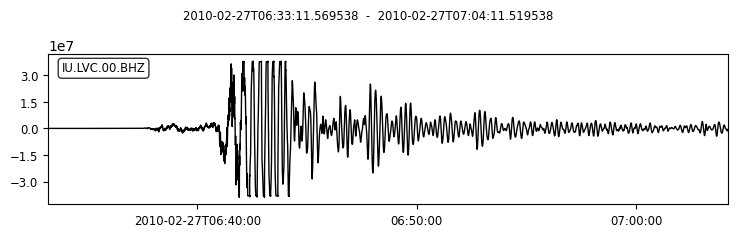

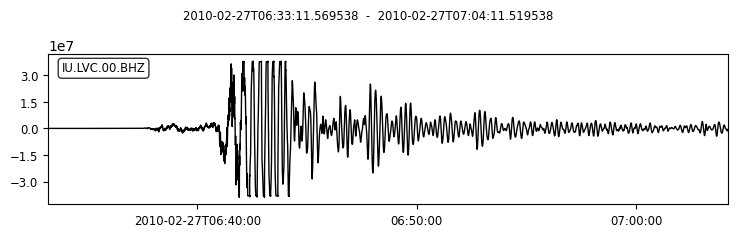

In [ ]:
st.plot();

In [ ]:

trace = st[0]
#construir dataframe con columnas tiempo y amplitud
df = pd.DataFrame({"tiempo_s": trace.times(), "amplitud": trace.data})
df.head()

/home/ezequel/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,tiempo_s,amplitud
0,0.00,2028
1,0.05,1973
2,0.10,1931
3,0.15,1894
4,0.20,1825


In [ ]:
#tipos de dato y cantidad de registros por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37200 entries, 0 to 37199
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tiempo_s  37200 non-null  float64
 1   amplitud  37200 non-null  int32  
dtypes: float64(1), int32(1)
memory usage: 436.1 KB


In [ ]:
#estadisticas descriptivas basicas de cada columna
df.describe()

,tiempo_s,amplitud
count,37200.000000,3.720000e+04
mean,929.975000,1.487626e+04
std,536.942967,9.661958e+06
min,0.000000,-3.893963e+07
25%,464.987500,-1.617710e+06
50%,929.975000,2.023000e+03
75%,1394.962500,1.777808e+06
max,1859.950000,3.796414e+07


In [ ]:
#cantidad de valores nulos por columna
df.isnull().sum()

tiempo_s    0
amplitud    0
dtype: int64

<Axes: >

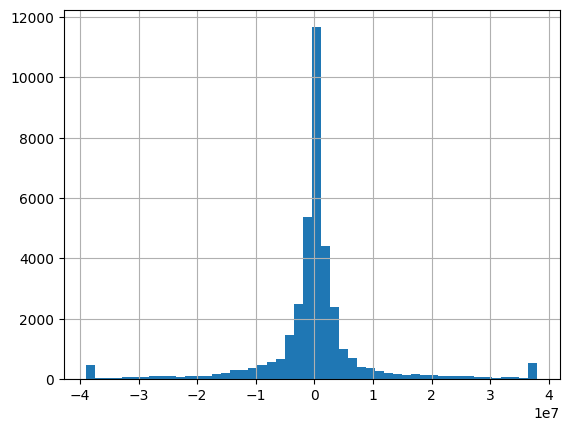

In [ ]:
#distribucion de la columna amplitud
df["amplitud"].hist(bins=50);

In [ ]:
#valores minimo y maximo de la columna amplitud
print(df["amplitud"].min(), df["amplitud"].max())

-38939634 37964140
